In [ ]:
# ============================================================
# Lab Work 1 Task 2: Classification after record deletion
# Author: Maria Malykhina (Group 1)
# ============================================================
# In Task 1 we observed that for most attributes the histograms of Y=0
# and Y=1 overlap strongly, which limits classifier accuracy
# (~0.76 baseline). In Task 2 we artificially "clean" the dataset:
# we pick two strongly overlapping attributes (pH and residual sugar),
# do a density analysis, and delete records from the central
# overlap region. We then re-run the same 10-run GridSearch SVM pipeline
# as in Task 1c and compare accuracy with the baseline.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 100

# Load the same dataset as Task 1.
df = pd.read_csv("../Wine_Test_01.csv")

print("Original dataset shape:", df.shape)
print("\nClass balance (Y = quality):")
print(df["quality"].value_counts())

Original dataset shape: (1143, 12)

Class balance (Y = quality):
quality
1    621
0    522
Name: count, dtype: int64


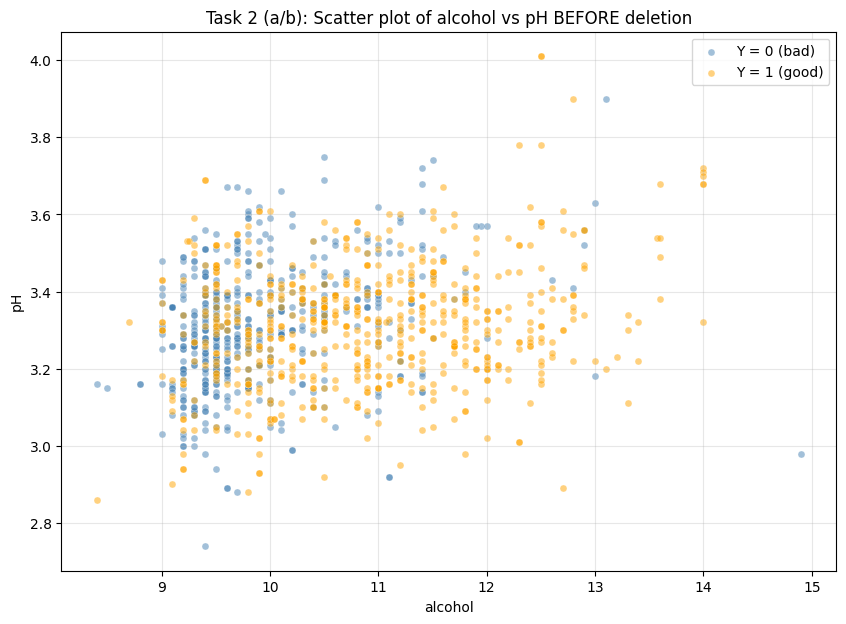


Statistics for alcohol (X axis):
count    1143.000000
mean       10.442111
std         1.082196
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64

Statistics for pH (Y axis):
count    1143.000000
mean        3.311015
std         0.156664
min         2.740000
25%         3.205000
50%         3.310000
75%         3.400000
max         4.010000
Name: pH, dtype: float64


In [4]:
# ============================================================
# Task 2 (a, b): Density analysis (scatter plot) before deletion
# ============================================================
# We choose alcohol (X axis) and pH (Y axis) for the scatter plot.
#   - alcohol shows a clear class separation in Task 1(b):
#     Y=0 (bad) is centred around ~9.5%, Y=1 (good) around ~11%.
#   - pH overlaps strongly (Y=0 and Y=1 histograms nearly identical).
# This combination matches the spirit of Fig. 2 in the assignment
# (one "separating" attribute paired with one "overlapping" attribute).
# Removing a middle corridor along the alcohol axis will create a
# visible gap between the two class clouds.

attr_x = "alcohol"
attr_y = "pH"

df_bad  = df[df["quality"] == 0]
df_good = df[df["quality"] == 1]

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_bad[attr_x],  df_bad[attr_y],  alpha=0.5, s=25,
           color="steelblue", label="Y = 0 (bad)",  edgecolor="white", linewidth=0.3)
ax.scatter(df_good[attr_x], df_good[attr_y], alpha=0.5, s=25,
           color="orange",    label="Y = 1 (good)", edgecolor="white", linewidth=0.3)

ax.set_xlabel(attr_x)
ax.set_ylabel(attr_y)
ax.set_title(f"Task 2 (a/b): Scatter plot of {attr_x} vs {attr_y} BEFORE deletion")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"\nStatistics for {attr_x} (X axis):")
print(df[attr_x].describe())
print(f"\nStatistics for {attr_y} (Y axis):")
print(df[attr_y].describe())

Original size:  1143 rows  (522 bad / 621 good)
Cleaned size:   889 rows  (415 bad / 474 good)
Removed:        254 rows (22.2%)


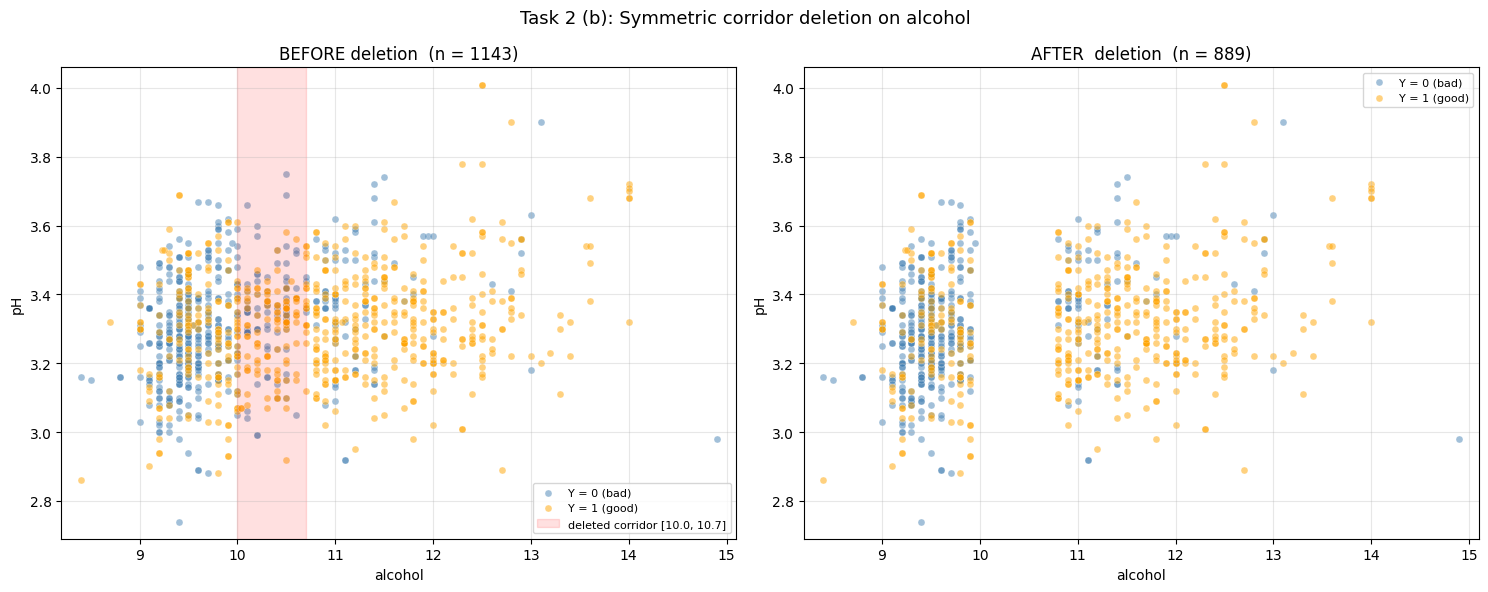

In [5]:
# ============================================================
# Task 2 (b): Apply symmetric corridor deletion on alcohol
# ============================================================
# As described in the assignment, records are deleted that lie in a
# given value range of the chosen attribute, so that the histogram
# peaks of Y=0 and Y=1 become separated.
#
# We delete all records (both classes) whose alcohol value falls in
# the central "overlap" corridor [10.0, 10.7]. After this deletion:
#   - the remaining Y=0 sit mostly below alcohol = 10.0
#   - the remaining Y=1 sit mostly above alcohol = 10.7
# producing two visually distinct class clouds, matching the example
# in Fig. 2 of the assignment.

ALC_LOW  = 10.0   # lower bound of the deleted corridor
ALC_HIGH = 10.7   # upper bound of the deleted corridor

# Keep rows that are OUTSIDE the corridor
keep_mask = (df["alcohol"] < ALC_LOW) | (df["alcohol"] > ALC_HIGH)
df_clean  = df[keep_mask].copy()

print(f"Original size:  {len(df)} rows  "
      f"({(df['quality']==0).sum()} bad / {(df['quality']==1).sum()} good)")
print(f"Cleaned size:   {len(df_clean)} rows  "
      f"({(df_clean['quality']==0).sum()} bad / {(df_clean['quality']==1).sum()} good)")
print(f"Removed:        {len(df) - len(df_clean)} rows "
      f"({100 * (len(df) - len(df_clean)) / len(df):.1f}%)")

# ---- Visual comparison: before vs after ----
df_bad_clean  = df_clean[df_clean["quality"] == 0]
df_good_clean = df_clean[df_clean["quality"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: before
axes[0].scatter(df[df["quality"]==0]["alcohol"], df[df["quality"]==0]["pH"],
                alpha=0.5, s=25, color="steelblue", label="Y = 0 (bad)",
                edgecolor="white", linewidth=0.3)
axes[0].scatter(df[df["quality"]==1]["alcohol"], df[df["quality"]==1]["pH"],
                alpha=0.5, s=25, color="orange",    label="Y = 1 (good)",
                edgecolor="white", linewidth=0.3)
axes[0].axvspan(ALC_LOW, ALC_HIGH, color="red", alpha=0.12,
                label=f"deleted corridor [{ALC_LOW}, {ALC_HIGH}]")
axes[0].set_xlabel("alcohol")
axes[0].set_ylabel("pH")
axes[0].set_title(f"BEFORE deletion  (n = {len(df)})")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: after
axes[1].scatter(df_bad_clean["alcohol"],  df_bad_clean["pH"],
                alpha=0.5, s=25, color="steelblue", label="Y = 0 (bad)",
                edgecolor="white", linewidth=0.3)
axes[1].scatter(df_good_clean["alcohol"], df_good_clean["pH"],
                alpha=0.5, s=25, color="orange",    label="Y = 1 (good)",
                edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("alcohol")
axes[1].set_ylabel("pH")
axes[1].set_title(f"AFTER  deletion  (n = {len(df_clean)})")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Common axis limits
for ax in axes:
    ax.set_xlim(df["alcohol"].min() - 0.2, df["alcohol"].max() + 0.2)
    ax.set_ylim(df["pH"].min()      - 0.05, df["pH"].max()      + 0.05)

fig.suptitle("Task 2 (b): Symmetric corridor deletion on alcohol", fontsize=13)
fig.tight_layout()
plt.show()

In [7]:
# ============================================================
# Task 2 (c): 10 runs of modelling and test on the cleaned dataset
# ============================================================
# Identical pipeline and identical hyperparameter grid as in Task 1(c),
# only the input data has changed:
#   Task 1 used the full 1143-row dataset
#   Task 2 uses the 889-row cleaned dataset (after corridor deletion)
# Any change in accuracy is therefore attributable to the record
# deletion, not to the modelling choices.

# ---- Inputs from the cleaned dataset ----
X_clean = df_clean.drop(columns=["quality"])
y_clean = df_clean["quality"]

# ---- Pipeline: same as Task 1(c) ----
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC()),
])

param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C":      [0.1, 1, 10, 100, 1000],
    "svm__gamma":  [1, 0.1, 0.01, 0.001, 0.0001],
}

# ---- 10 runs ----
N_RUNS = 10
accuracies  = []
best_params = []

print("Running 10 train/test runs on the cleaned dataset\n")

for run in range(N_RUNS):
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.20, random_state=run, stratify=y_clean
    )

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    test_acc = grid.score(X_test, y_test)
    accuracies.append(test_acc)
    best_params.append(grid.best_params_)

    print(f"Run {run + 1:2d}  accuracy = {test_acc:.4f}  "
          f"best params = {grid.best_params_}")

# ---- Summary ----
mean_acc = np.mean(accuracies)
std_acc  = np.std(accuracies)

print("\n" + "=" * 60)
print(f"Task 2c summary over {N_RUNS} runs (cleaned dataset, n = {len(df_clean)})")
print(f"  Mean accuracy: {mean_acc:.4f}")
print(f"  Std  accuracy: {std_acc:.4f}")
print("=" * 60)

# ---- Comparison with Task 1 baseline ----
TASK1_MEAN = 0.7576    # from Task 1c
TASK1_STD  = 0.0277
diff = mean_acc - TASK1_MEAN
print(f"\nTask 1 baseline (full data,  n = 1143): {TASK1_MEAN:.4f} +/- {TASK1_STD:.4f}")
print(f"Task 2          (cleaned data, n = {len(df_clean)}): {mean_acc:.4f} +/- {std_acc:.4f}")
print(f"Change: {diff:+.4f}  ({100*diff/TASK1_MEAN:+.1f}%)")

Running 10 train/test runs on the cleaned dataset

Run  1  accuracy = 0.7528  best params = {'svm__C': 1000, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  2  accuracy = 0.7416  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  3  accuracy = 0.7865  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  4  accuracy = 0.7865  best params = {'svm__C': 1000, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  5  accuracy = 0.7809  best params = {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  6  accuracy = 0.7640  best params = {'svm__C': 0.1, 'svm__gamma': 1, 'svm__kernel': 'linear'}
Run  7  accuracy = 0.7809  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  8  accuracy = 0.7528  best params = {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  9  accuracy = 0.7640  best params = {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Run 10  accuracy = 0.8034  best params = {'svm__C': 10, 'svm__ga

In [8]:
# ============================================================
# Task 2 (extra): Side experiments for deeper understanding
# ============================================================
# To understand which factor really drives the accuracy change, we
# compare four configurations using the SAME pipeline as Task 1c:
#
#   E1  full data, all 11 attributes              (= Task 1c baseline)
#   E2  full data, only [alcohol, pH]             (= 2-attribute baseline)
#   E3  cleaned data, all 11 attributes           (= Task 2c proper)
#   E4  cleaned data, only [alcohol, pH]          (= 2-attribute + cleaned)
#
# E1 vs E3 isolates the effect of RECORD deletion (rows removed).
# E1 vs E2 isolates the effect of ATTRIBUTE reduction (columns removed).
# This is just an exploratory comparison, not part of the formal
# Task 2 deliverable. The result reported for Task 2c is E3.

def run_10_runs(X_in, y_in, label):
    """
    Run the identical 10-run GridSearch SVM pipeline as in Task 1c
    on arbitrary inputs X_in, y_in. Returns (mean, std).
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC()),
    ])
    grid_params = {
        "svm__kernel": ["linear", "rbf"],
        "svm__C":      [0.1, 1, 10, 100, 1000],
        "svm__gamma":  [1, 0.1, 0.01, 0.001, 0.0001],
    }
    accs = []
    for run in range(10):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_in, y_in, test_size=0.20, random_state=run, stratify=y_in
        )
        grid = GridSearchCV(pipe, grid_params, cv=5,
                            scoring="accuracy", n_jobs=-1)
        grid.fit(X_tr, y_tr)
        accs.append(grid.score(X_te, y_te))
    return np.mean(accs), np.std(accs), label

# Two attributes selected in Task 2(a)
two_attr_cols = ["alcohol", "pH"]
print("Running 4 experiments \n")

# E1: full data, all attributes (re-running for a clean comparison
e1 = run_10_runs(
    df.drop(columns=["quality"]),  df["quality"],
    f"E1: full data    ({len(df):4d} rows), all 11 attrs"
)
print(f"  done: {e1[2]} -> {e1[0]:.4f} +/- {e1[1]:.4f}")

# E2: full data, only 2 attributes
e2 = run_10_runs(
    df[two_attr_cols],             df["quality"],
    f"E2: full data    ({len(df):4d} rows), only [alcohol, pH]"
)
print(f"  done: {e2[2]} -> {e2[0]:.4f} +/- {e2[1]:.4f}")

# E3: cleaned data, all attributes
e3 = run_10_runs(
    df_clean.drop(columns=["quality"]), df_clean["quality"],
    f"E3: cleaned data ({len(df_clean):4d} rows), all 11 attrs   <-- Task 2c"
)
print(f"  done: {e3[2]} -> {e3[0]:.4f} +/- {e3[1]:.4f}")

# E4: cleaned data, only 2 attributes
e4 = run_10_runs(
    df_clean[two_attr_cols],       df_clean["quality"],
    f"E4: cleaned data ({len(df_clean):4d} rows), only [alcohol, pH]"
)
print(f"  done: {e4[2]} -> {e4[0]:.4f} +/- {e4[1]:.4f}")

# ---- Summary table ----
print("\n" + "=" * 75)
print("Comparison summary")
print("=" * 75)
for mean, std, label in [e1, e2, e3, e4]:
    print(f"  {label:55s}  {mean:.4f} +/- {std:.4f}")
print("=" * 75)

# Interpretation:
#   E1 vs E3:  effect of record deletion (with full features) -> small
#   E1 vs E2:  effect of dropping 9 attributes                 -> big
#   E2 vs E4:  effect of record deletion (with only 2 features)

Running 4 experiments (about 2-3 minutes total)

  done: E1: full data    (1143 rows), all 11 attrs -> 0.7576 +/- 0.0277
  done: E2: full data    (1143 rows), only [alcohol, pH] -> 0.7144 +/- 0.0327
  done: E3: cleaned data ( 889 rows), all 11 attrs   <-- Task 2c -> 0.7713 +/- 0.0183
  done: E4: cleaned data ( 889 rows), only [alcohol, pH] -> 0.7433 +/- 0.0195

Comparison summary
  E1: full data    (1143 rows), all 11 attrs               0.7576 +/- 0.0277
  E2: full data    (1143 rows), only [alcohol, pH]         0.7144 +/- 0.0327
  E3: cleaned data ( 889 rows), all 11 attrs   <-- Task 2c  0.7713 +/- 0.0183
  E4: cleaned data ( 889 rows), only [alcohol, pH]         0.7433 +/- 0.0195
